In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # so Python can find phast_bootstrap.py
import phast_bootstrap

[phast_bootstrap] ready. Colab paths now resolve under: C:\Users\Swara Deshpande\exoplanet-detection-isro


In [3]:
from google.colab import drive
drive.mount('/content/drive')

[pipeline] mock drive.mount — using local repo


In [4]:
import os
import copy
import pickle
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, TensorDataset


In [5]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)

PyTorch version: 2.12.1+cpu
Device: cpu


In [6]:
DATA_DIR = (
    "/content/drive/MyDrive/"
    "exoplanet_pipeline/data"
)

MODEL_DIR = (
    "/content/drive/MyDrive/"
    "exoplanet_pipeline/models"
)

os.makedirs(
    DATA_DIR,
    exist_ok=True
)

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

stage1_path = os.path.join(
    DATA_DIR,
    "stage1_output.pkl"
)

stage2_path = os.path.join(
    DATA_DIR,
    "stage2_output.pkl"
)

stage3_path = os.path.join(
    DATA_DIR,
    "stage3_output.pkl"
)

stage4_path = os.path.join(
    DATA_DIR,
    "stage4_output.pkl"
)

model_path = os.path.join(
    MODEL_DIR,
    "stage4_per_star_autoencoder.pt"
)

print("Stage 1:", stage1_path)
print("Stage 2:", stage2_path)
print("Stage 3:", stage3_path)
print("Stage 4:", stage4_path)
print("Model:", model_path)

Stage 1: /content/drive/MyDrive/exoplanet_pipeline/data\stage1_output.pkl
Stage 2: /content/drive/MyDrive/exoplanet_pipeline/data\stage2_output.pkl
Stage 3: /content/drive/MyDrive/exoplanet_pipeline/data\stage3_output.pkl
Stage 4: /content/drive/MyDrive/exoplanet_pipeline/data\stage4_output.pkl
Model: /content/drive/MyDrive/exoplanet_pipeline/models\stage4_per_star_autoencoder.pt


In [7]:
AUTOENCODER_CONFIG = {
    # Windowing
    "window_size": 200,
    "stride": 20,
    "window_duration_factor": 4.0,
    "minimum_window_size": 200,
    "maximum_window_size": 512,

    # Architecture
    "latent_size": 12,

    # Window quality
    "maximum_gap_factor": 5.0,
    "minimum_normal_windows": 60,
    "transit_exclusion_factor": 3.0,
    "stage2_uses_shifted_time": True,

    # Three-way chronological split
    "validation_fraction": 0.15,
    "calibration_fraction": 0.20,

    # Training
    "batch_size": 64,
    "learning_rate": 5e-4,
    "minimum_learning_rate": 1e-5,
    "weight_decay": 1e-4,
    "maximum_epochs": 150,
    "early_stopping_patience": 20,
    "early_stopping_min_delta": 1e-5,
    "scheduler_patience": 5,
    "scheduler_factor": 0.5,
    "gradient_clip_norm": 1.0,
    "input_noise_std": 0.10,
    "derivative_loss_weight": 0.10,

    # Threshold calibration
    "threshold_sigma": 5.0,
    "threshold_percentile": 99.0,

    # Scaling
    "minimum_scale": 1e-6,
    "clip_scaled_flux": 12.0,

    # Reliability test
    "fallback_injection_depth": 1e-3,
    "injection_depth_multipliers": [0.5, 1.0, 2.0],
    "injection_ingress_fraction": 0.20,

    # Contamination and noise warnings
    "blend_risk_threshold": 0.30,
    "variability_scatter_threshold": 0.02,

    # Stage 3 compatibility
    "allow_missing_stage3": True,
    "override_stage3_rejection": False
}

print(AUTOENCODER_CONFIG)


{'window_size': 200, 'stride': 20, 'window_duration_factor': 4.0, 'minimum_window_size': 200, 'maximum_window_size': 512, 'latent_size': 12, 'maximum_gap_factor': 5.0, 'minimum_normal_windows': 60, 'transit_exclusion_factor': 3.0, 'stage2_uses_shifted_time': True, 'validation_fraction': 0.15, 'calibration_fraction': 0.2, 'batch_size': 64, 'learning_rate': 0.0005, 'minimum_learning_rate': 1e-05, 'weight_decay': 0.0001, 'maximum_epochs': 150, 'early_stopping_patience': 20, 'early_stopping_min_delta': 1e-05, 'scheduler_patience': 5, 'scheduler_factor': 0.5, 'gradient_clip_norm': 1.0, 'input_noise_std': 0.1, 'derivative_loss_weight': 0.1, 'threshold_sigma': 5.0, 'threshold_percentile': 99.0, 'minimum_scale': 1e-06, 'clip_scaled_flux': 12.0, 'fallback_injection_depth': 0.001, 'injection_depth_multipliers': [0.5, 1.0, 2.0], 'injection_ingress_fraction': 0.2, 'blend_risk_threshold': 0.3, 'variability_scatter_threshold': 0.02, 'allow_missing_stage3': True, 'override_stage3_rejection': False}


In [8]:
with open(stage1_path, "rb") as f:
    stage1_data = pickle.load(f)

print("Stage 1 keys:")
print(stage1_data.keys())

Stage 1 keys:
dict_keys(['time', 'flux', 'flux_err', 'tic_id', 'crowdsap', 'ra', 'dec', 'sector'])


In [9]:
with open(stage2_path, "rb") as f:
    stage2_data = pickle.load(f)

print("Stage 2 keys:")
print(stage2_data.keys())

Stage 2 keys:
dict_keys(['period', 'sde', 'duration', 't0', 'depth_tls', 'snr_tls', 'distinct_transit_count', 'odd_even_mismatch_tls'])


In [10]:
stage3_data = None
stage3_available = os.path.exists(
    stage3_path
)

stage3_decision = None

if stage3_available:
    with open(stage3_path, "rb") as f:
        stage3_data = pickle.load(f)

    stage3_decision = stage3_data.get(
        "decision",
        stage3_data.get("status")
    )

    print("Stage 3 output found.")
    print(
        "Stage 3 decision:",
        stage3_decision
    )

    if (
        str(stage3_decision).upper()
        == "REJECTED"
        and not AUTOENCODER_CONFIG[
            "override_stage3_rejection"
        ]
    ):
        raise RuntimeError(
            "Stage 3 rejected this candidate. "
            "Stage 4 should not run."
        )

else:
    print(
        "Stage 3 output is not available yet."
    )

    if not AUTOENCODER_CONFIG[
        "allow_missing_stage3"
    ]:
        raise FileNotFoundError(
            "stage3_output.pkl was not found."
        )

    print(
        "Continuing with Stage 1 "
        "and Stage 2 only."
    )

Stage 3 output is not available yet.
Continuing with Stage 1 and Stage 2 only.


In [11]:
time = np.asarray(
    stage1_data["time"],
    dtype=float
)

flux = np.asarray(
    stage1_data["flux"],
    dtype=float
)

flux_err = np.asarray(
    stage1_data["flux_err"],
    dtype=float
)

valid = (
    np.isfinite(time)
    & np.isfinite(flux)
    & np.isfinite(flux_err)
)

time = time[valid]
flux = flux[valid]
flux_err = flux_err[valid]

order = np.argsort(time)

time = time[order]
flux = flux[order]
flux_err = flux_err[order]

if len(time) < AUTOENCODER_CONFIG[
    "window_size"
]:
    raise ValueError(
        "The light curve has fewer than "
        "200 valid data points."
    )

if AUTOENCODER_CONFIG[
    "stage2_uses_shifted_time"
]:
    model_time = (
        time - np.min(time)
    )
else:
    model_time = time.copy()

print("Valid cadences:", len(time))

print(
    "Time range:",
    model_time.min(),
    "to",
    model_time.max()
)

Valid cadences: 18261
Time range: 0.0 to 27.880105402320623


In [12]:
median_flux = np.nanmedian(flux)

if -0.20 < median_flux < 0.20:
    flux_normalized = flux + 1.0

    flux_err_normalized = (
        flux_err.copy()
    )

    normalization_mode = (
        "added 1.0"
    )

else:
    flux_normalized = (
        flux / median_flux
    )

    flux_err_normalized = (
        flux_err / abs(median_flux)
    )

    normalization_mode = (
        "divided by median"
    )

cadence_days = np.nanmedian(
    np.diff(model_time)
)

cadence_minutes = (
    cadence_days
    * 24.0
    * 60.0
)

window_hours = (
    AUTOENCODER_CONFIG["window_size"]
    * cadence_minutes
    / 60.0
)

print(
    "Original median:",
    median_flux
)

print(
    "Normalized median:",
    np.nanmedian(flux_normalized)
)

print(
    "Normalization:",
    normalization_mode
)

print(
    "Median cadence:",
    cadence_minutes,
    "minutes"
)

print(
    "200-point window:",
    window_hours,
    "hours"
)

Original median: 0.0
Normalized median: 1.0
Normalization: added 1.0
Median cadence: 1.999967023730278 minutes
200-point window: 6.666556745767593 hours


In [13]:
period = float(
    stage2_data["period"]
)

duration = float(
    stage2_data["duration"]
)

t0 = float(
    stage2_data["t0"]
)

sde = float(
    stage2_data.get(
        "sde",
        stage2_data.get(
            "SDE",
            np.nan
        )
    )
)

if period <= 0:
    raise ValueError(
        "Stage 2 period must be positive."
    )

if duration <= 0:
    raise ValueError(
        "Stage 2 duration must be positive."
    )

print("Period:", period)
print("Duration:", duration)
print("T0:", t0)
print("SDE:", sde)

Period: 6.267090136076321
Duration: 0.12476139841324797
T0: 0.20952101445453392
SDE: 17.69836307589993


In [14]:
# Choose a window with enough context around the Stage 2 transit.
# It is rounded to a multiple of 8 because the Conv1D encoder downsamples 3 times.
duration_points = max(
    1,
    int(np.ceil(duration / cadence_days))
)

suggested_window_size = int(
    np.ceil(
        AUTOENCODER_CONFIG["window_duration_factor"]
        * duration_points
        / 8.0
    )
    * 8
)

AUTOENCODER_CONFIG["window_size"] = int(
    np.clip(
        suggested_window_size,
        AUTOENCODER_CONFIG["minimum_window_size"],
        AUTOENCODER_CONFIG["maximum_window_size"]
    )
)

AUTOENCODER_CONFIG["stride"] = max(
    8,
    AUTOENCODER_CONFIG["window_size"] // 10
)

if len(model_time) < AUTOENCODER_CONFIG["window_size"]:
    raise ValueError(
        "The light curve is shorter than the duration-aware autoencoder window."
    )

window_hours = (
    AUTOENCODER_CONFIG["window_size"]
    * cadence_minutes
    / 60.0
)

print("Transit duration in cadences:", duration_points)
print("Final window size:", AUTOENCODER_CONFIG["window_size"])
print("Final stride:", AUTOENCODER_CONFIG["stride"])
print("Final window duration:", window_hours, "hours")


Transit duration in cadences: 90
Final window size: 360
Final stride: 36
Final window duration: 11.999802142381668 hours


In [15]:
transit_number = np.rint(
    (model_time - t0) / period
).astype(int)

nearest_transit_center = (
    t0
    + transit_number * period
)

distance_from_transit = np.abs(
    model_time
    - nearest_transit_center
)

transit_half_width = (
    AUTOENCODER_CONFIG[
        "transit_exclusion_factor"
    ]
    * duration
    / 2.0
)

predicted_transit_mask = (
    distance_from_transit
    <= transit_half_width
)

first_transit_number = int(
    np.floor(
        (model_time.min() - t0)
        / period
    )
) - 1

last_transit_number = int(
    np.ceil(
        (model_time.max() - t0)
        / period
    )
) + 1

all_transit_centers = (
    t0
    + np.arange(
        first_transit_number,
        last_transit_number + 1
    )
    * period
)

visible_transit_centers = (
    all_transit_centers[
        (
            all_transit_centers
            >= model_time.min()
        )
        &
        (
            all_transit_centers
            <= model_time.max()
        )
    ]
)

print(
    "Transit cadences:",
    predicted_transit_mask.sum()
)

print(
    "Visible transits:",
    len(visible_transit_centers)
)

Transit cadences: 1336
Visible transits: 5


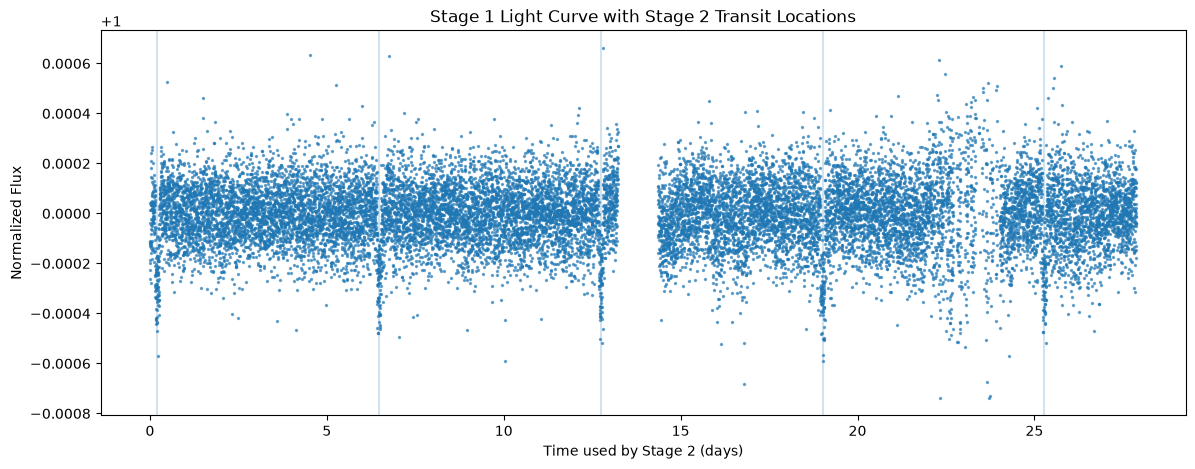

In [16]:
plt.figure(figsize=(14, 5))

plt.scatter(
    model_time,
    flux_normalized,
    s=2,
    alpha=0.60
)

for center in visible_transit_centers:
    plt.axvline(
        center,
        alpha=0.20
    )

plt.xlabel(
    "Time used by Stage 2 (days)"
)

plt.ylabel(
    "Normalized Flux"
)

plt.title(
    "Stage 1 Light Curve with "
    "Stage 2 Transit Locations"
)

plt.show()

In [17]:
def create_light_curve_windows(
    time_values,
    flux_values,
    transit_mask,
    window_size,
    stride,
    maximum_gap_factor
):
    cadence = np.nanmedian(np.diff(time_values))

    windows = []
    start_indices = []
    end_indices = []
    center_times = []
    contains_transit = []

    for start in range(0,len(flux_values)- window_size+ 1,stride):
        end = start + window_size

        current_time = (time_values[start:end])

        current_flux = (flux_values[start:end])

        gaps = np.diff(current_time)

        if np.any(gaps> maximum_gap_factor* cadence):
            continue

        if not np.all(np.isfinite(current_flux)):
            continue

        windows.append(current_flux)

        start_indices.append(start)

        end_indices.append(end)

        center_times.append(current_time[window_size // 2])

        contains_transit.append(
            bool(
                np.any(
                    transit_mask[
                        start:end
                    ]
                )
            )
        )

    return {
        "windows": np.asarray(
            windows,
            dtype=np.float32
        ),

        "start_indices": np.asarray(
            start_indices,
            dtype=int
        ),

        "end_indices": np.asarray(
            end_indices,
            dtype=int
        ),

        "center_times": np.asarray(
            center_times,
            dtype=float
        ),

        "contains_transit": np.asarray(
            contains_transit,
            dtype=bool
        )
    }

In [18]:
window_data = (
    create_light_curve_windows(
        time_values=model_time,

        flux_values=(
            flux_normalized
        ),

        transit_mask=(
            predicted_transit_mask
        ),

        window_size=(
            AUTOENCODER_CONFIG[
                "window_size"
            ]
        ),

        stride=(
            AUTOENCODER_CONFIG[
                "stride"
            ]
        ),

        maximum_gap_factor=(
            AUTOENCODER_CONFIG[
                "maximum_gap_factor"
            ]
        )
    )
)

all_windows_raw = (
    window_data["windows"]
)

window_start_indices = (
    window_data["start_indices"]
)

window_end_indices = (
    window_data["end_indices"]
)

window_center_times = (
    window_data["center_times"]
)

window_contains_transit = (
    window_data["contains_transit"]
)

normal_window_mask = (
    ~window_contains_transit
)

print(
    "All valid windows:",
    len(all_windows_raw)
)

print(
    "Normal windows:",
    normal_window_mask.sum()
)

print(
    "Transit-overlapping windows:",
    window_contains_transit.sum()
)

if (
    normal_window_mask.sum()
    < AUTOENCODER_CONFIG[
        "minimum_normal_windows"
    ]
):
    raise ValueError(
        "Not enough normal windows "
        "remain after transit exclusion."
    )

All valid windows: 369
Normal windows: 312
Transit-overlapping windows: 57


In [19]:
window_start_times = (
    model_time[
        window_start_indices
    ]
)

window_end_times = (
    model_time[
        window_end_indices - 1
    ]
)

window_duration_days = (
    AUTOENCODER_CONFIG["window_size"]
    * cadence_days
)

# Each block is much larger than one window.
# Windows crossing block boundaries are discarded.
block_duration_days = max(
    4.0 * window_duration_days,
    1.0
)

start_block_ids = np.floor(
    (
        window_start_times
        - model_time.min()
    )
    / block_duration_days
).astype(int)

end_block_ids = np.floor(
    (
        window_end_times
        - model_time.min()
    )
    / block_duration_days
).astype(int)

window_stays_inside_block = (
    start_block_ids
    == end_block_ids
)

# Repeating five-block pattern:
# 0, 1, 2 -> training
# 3       -> validation
# 4       -> calibration
block_roles = (
    start_block_ids % 5
)

train_window_mask = (
    normal_window_mask
    & window_stays_inside_block
    & np.isin(
        block_roles,
        [0, 1, 2]
    )
)

validation_window_mask = (
    normal_window_mask
    & window_stays_inside_block
    & (block_roles == 3)
)

calibration_window_mask = (
    normal_window_mask
    & window_stays_inside_block
    & (block_roles == 4)
)

print(
    "Block duration:",
    block_duration_days,
    "days"
)

print(
    "Training windows:",
    train_window_mask.sum()
)

print(
    "Validation windows:",
    validation_window_mask.sum()
)

print(
    "Calibration windows:",
    calibration_window_mask.sum()
)

if (
    train_window_mask.sum() < 30
    or validation_window_mask.sum() < 10
    or calibration_window_mask.sum() < 10
):
    raise ValueError(
        "Insufficient windows after "
        "blocked temporal splitting."
    )

Block duration: 1.999967023730278 days
Training windows: 144
Validation windows: 44
Calibration windows: 38


In [20]:
# Remove each window's local baseline, then fit the robust scale on training only.
window_offsets = np.nanmedian(
    all_windows_raw,
    axis=1,
    keepdims=True
)

all_windows_centered = (
    all_windows_raw
    - window_offsets
)

training_centered_values = (
    all_windows_centered[
        train_window_mask
    ].reshape(-1)
)

normal_center = 0.0

training_median = np.nanmedian(
    training_centered_values
)

training_mad = np.nanmedian(
    np.abs(
        training_centered_values
        - training_median
    )
)

normal_scale = 1.4826 * training_mad

if (
    not np.isfinite(normal_scale)
    or normal_scale < AUTOENCODER_CONFIG["minimum_scale"]
):
    normal_scale = np.nanstd(
        training_centered_values
    )

if (
    not np.isfinite(normal_scale)
    or normal_scale < AUTOENCODER_CONFIG["minimum_scale"]
):
    normal_scale = AUTOENCODER_CONFIG["minimum_scale"]

all_windows_scaled = (
    all_windows_centered
    / normal_scale
)

all_windows_scaled = np.clip(
    all_windows_scaled,
    -AUTOENCODER_CONFIG["clip_scaled_flux"],
    AUTOENCODER_CONFIG["clip_scaled_flux"]
).astype(np.float32)

train_windows = all_windows_scaled[
    train_window_mask
]

validation_windows = all_windows_scaled[
    validation_window_mask
]

calibration_windows = all_windows_scaled[
    calibration_window_mask
]

print("Robust training scale:", normal_scale)
print("All scaled windows:", all_windows_scaled.shape)
print("Training windows:", train_windows.shape)
print("Validation windows:", validation_windows.shape)
print("Calibration windows:", calibration_windows.shape)


Robust training scale: 0.00011364362
All scaled windows: (369, 360)
Training windows: (144, 360)
Validation windows: (44, 360)
Calibration windows: (38, 360)


In [21]:
train_tensor = torch.tensor(train_windows,dtype=torch.float32)

validation_tensor = torch.tensor(validation_windows,dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(train_tensor),
    batch_size=(
        AUTOENCODER_CONFIG[
            "batch_size"
        ]
    ),
    shuffle=True,
    num_workers=0,
    pin_memory=(
        torch.cuda.is_available()
    )
)

validation_loader = DataLoader(
    TensorDataset(validation_tensor),
    batch_size=(
        AUTOENCODER_CONFIG[
            "batch_size"
        ]
    ),
    shuffle=False,
    num_workers=0,
    pin_memory=(torch.cuda.is_available())
)

print("Training batches:",len(train_loader))

print("Validation batches:",len(validation_loader))

Training batches: 3
Validation batches: 1


In [22]:
class PerStarAutoencoder(nn.Module):
    def __init__(
        self,
        input_size=200,
        latent_size=12
    ):
        super().__init__()

        if input_size % 8 != 0:
            raise ValueError(
                "input_size must be divisible by 8."
            )

        self.input_size = input_size
        self.encoded_length = input_size // 8

        self.encoder_conv = nn.Sequential(
            nn.Conv1d(
                1, 16,
                kernel_size=7,
                stride=2,
                padding=3
            ),
            nn.GELU(),

            nn.Conv1d(
                16, 32,
                kernel_size=5,
                stride=2,
                padding=2
            ),
            nn.GELU(),

            nn.Conv1d(
                32, 64,
                kernel_size=5,
                stride=2,
                padding=2
            ),
            nn.GELU()
        )

        self.to_latent = nn.Linear(
            64 * self.encoded_length,
            latent_size
        )

        self.from_latent = nn.Linear(
            latent_size,
            64 * self.encoded_length
        )

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose1d(
                64, 32,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.GELU(),

            nn.ConvTranspose1d(
                32, 16,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.GELU(),

            nn.ConvTranspose1d(
                16, 1,
                kernel_size=4,
                stride=2,
                padding=1
            )
        )

    def encode(self, x):
        encoded = self.encoder_conv(
            x.unsqueeze(1)
        )

        return self.to_latent(
            encoded.flatten(start_dim=1)
        )

    def forward(self, x):
        latent = self.encode(x)

        decoded = self.from_latent(latent).view(
            x.shape[0],
            64,
            self.encoded_length
        )

        reconstruction = (
            self.decoder_conv(decoded)
            .squeeze(1)
        )

        return reconstruction[
            :,
            :self.input_size
        ]


In [23]:
model = PerStarAutoencoder(
    input_size=AUTOENCODER_CONFIG["window_size"],
    latent_size=AUTOENCODER_CONFIG["latent_size"]
).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=AUTOENCODER_CONFIG["learning_rate"],
    weight_decay=AUTOENCODER_CONFIG["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=AUTOENCODER_CONFIG["scheduler_factor"],
    patience=AUTOENCODER_CONFIG["scheduler_patience"],
    min_lr=AUTOENCODER_CONFIG["minimum_learning_rate"]
)

def autoencoder_loss(
    reconstruction,
    target
):
    point_loss = F.mse_loss(
        reconstruction,
        target
    )

    reconstruction_difference = (
        reconstruction[:, 1:]
        - reconstruction[:, :-1]
    )

    target_difference = (
        target[:, 1:]
        - target[:, :-1]
    )

    derivative_loss = F.mse_loss(
        reconstruction_difference,
        target_difference
    )

    return (
        point_loss
        + AUTOENCODER_CONFIG["derivative_loss_weight"]
        * derivative_loss
    )

print(model)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Trainable parameters:", trainable_parameters)


PerStarAutoencoder(
  (encoder_conv): Sequential(
    (0): Conv1d(1, 16, kernel_size=(7,), stride=(2,), padding=(3,))
    (1): GELU(approximate='none')
    (2): Conv1d(16, 32, kernel_size=(5,), stride=(2,), padding=(2,))
    (3): GELU(approximate='none')
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(2,), padding=(2,))
    (5): GELU(approximate='none')
  )
  (to_latent): Linear(in_features=2880, out_features=12, bias=True)
  (from_latent): Linear(in_features=12, out_features=2880, bias=True)
  (decoder_conv): Sequential(
    (0): ConvTranspose1d(64, 32, kernel_size=(4,), stride=(2,), padding=(1,))
    (1): GELU(approximate='none')
    (2): ConvTranspose1d(32, 16, kernel_size=(4,), stride=(2,), padding=(1,))
    (3): GELU(approximate='none')
    (4): ConvTranspose1d(16, 1, kernel_size=(4,), stride=(2,), padding=(1,))
  )
)
Trainable parameters: 95389


In [24]:
training_history = {
    "train_loss": [],
    "validation_loss": [],
    "learning_rate": []
}

best_validation_loss = np.inf
best_model_state = None
epochs_without_improvement = 0

for epoch in range(
    1,
    AUTOENCODER_CONFIG["maximum_epochs"] + 1
):
    model.train()

    # Denoising training: noisy normal input -> clean normal target.
    for (batch,) in train_loader:
        batch = batch.to(
            DEVICE,
            non_blocking=True
        )

        noisy_batch = (
            batch
            + AUTOENCODER_CONFIG["input_noise_std"]
            * torch.randn_like(batch)
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        reconstruction = model(
            noisy_batch
        )

        loss = autoencoder_loss(
            reconstruction,
            batch
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            AUTOENCODER_CONFIG["gradient_clip_norm"]
        )

        optimizer.step()

    # Evaluate clean train and validation reconstruction.
    model.eval()

    total_train_loss = 0.0
    total_train_items = 0
    total_validation_loss = 0.0
    total_validation_items = 0

    with torch.no_grad():
        for (batch,) in train_loader:
            batch = batch.to(
                DEVICE,
                non_blocking=True
            )

            reconstruction = model(
                batch
            )

            loss = autoencoder_loss(
                reconstruction,
                batch
            )

            total_train_loss += (
                loss.item()
                * len(batch)
            )

            total_train_items += len(batch)

        for (batch,) in validation_loader:
            batch = batch.to(
                DEVICE,
                non_blocking=True
            )

            reconstruction = model(
                batch
            )

            loss = autoencoder_loss(
                reconstruction,
                batch
            )

            total_validation_loss += (
                loss.item()
                * len(batch)
            )

            total_validation_items += len(batch)

    train_loss = (
        total_train_loss
        / max(total_train_items, 1)
    )

    validation_loss = (
        total_validation_loss
        / max(total_validation_items, 1)
    )

    scheduler.step(
        validation_loss
    )

    training_history["train_loss"].append(
        train_loss
    )

    training_history["validation_loss"].append(
        validation_loss
    )

    training_history["learning_rate"].append(
        optimizer.param_groups[0]["lr"]
    )

    if (
        validation_loss
        < best_validation_loss
        - AUTOENCODER_CONFIG["early_stopping_min_delta"]
    ):
        best_validation_loss = (
            validation_loss
        )

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Train: {train_loss:.6f} | "
            f"Validation: {validation_loss:.6f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.2e}"
        )

    if (
        epochs_without_improvement
        >= AUTOENCODER_CONFIG["early_stopping_patience"]
    ):
        print(
            "Early stopping at epoch:",
            epoch
        )
        break

if best_model_state is None:
    raise RuntimeError(
        "Training did not produce a valid model."
    )

model.load_state_dict(
    best_model_state
)

completed_epochs = len(
    training_history["train_loss"]
)

print("Completed epochs:", completed_epochs)
print("Best validation loss:", best_validation_loss)


Epoch 001 | Train: 1.229738 | Validation: 1.264048 | LR: 5.00e-04


Epoch 010 | Train: 1.202122 | Validation: 1.249768 | LR: 5.00e-04


Epoch 020 | Train: 1.170762 | Validation: 1.244465 | LR: 5.00e-04


Epoch 030 | Train: 1.107697 | Validation: 1.235745 | LR: 5.00e-04


Epoch 040 | Train: 1.069771 | Validation: 1.238358 | LR: 1.25e-04


Early stopping at epoch: 47
Completed epochs: 47
Best validation loss: 1.233610987663269


In [25]:
best_epoch = (
    np.argmin(
        training_history["validation_loss"]
    ) + 1
)

best_train_loss = (
    training_history["train_loss"][
        best_epoch - 1
    ]
)

best_validation_loss = (
    training_history["validation_loss"][
        best_epoch - 1
    ]
)

print("Best epoch:", best_epoch)
print("Training loss at best epoch:", best_train_loss)
print(
    "Validation loss at best epoch:",
    best_validation_loss
)

print(
    "Generalization gap:",
    best_validation_loss
    - best_train_loss
)

Best epoch: 27
Training loss at best epoch: 1.1251109838485718
Validation loss at best epoch: 1.233610987663269
Generalization gap: 0.10850000381469727


In [26]:
train_raw_windows = all_windows_raw[
    train_window_mask
]

validation_raw_windows = all_windows_raw[
    validation_window_mask
]

print(
    "Training median:",
    np.median(train_raw_windows)
)

print(
    "Validation median:",
    np.median(validation_raw_windows)
)

print(
    "Training standard deviation:",
    np.std(train_raw_windows)
)

print(
    "Validation standard deviation:",
    np.std(validation_raw_windows)
)

Training median: 0.99999934
Validation median: 1.0000043
Training standard deviation: 0.00011518184
Validation standard deviation: 0.00011786294


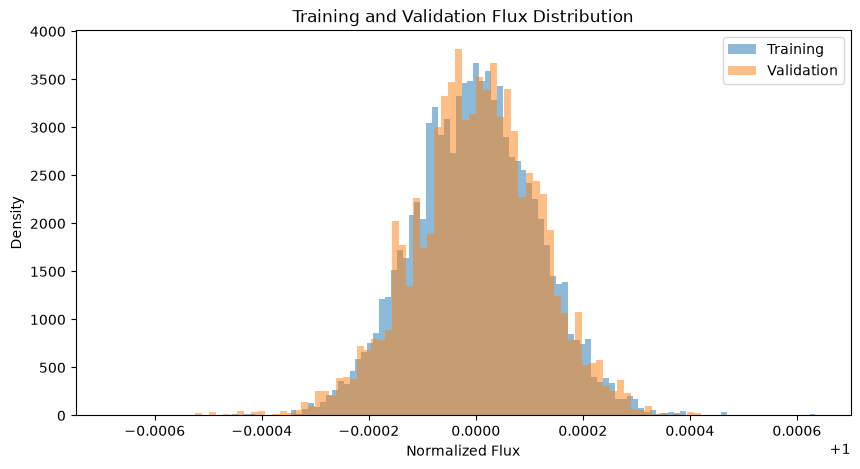

In [27]:
plt.figure(figsize=(10, 5))

plt.hist(
    train_raw_windows.reshape(-1),
    bins=100,
    alpha=0.50,
    density=True,
    label="Training"
)

plt.hist(
    validation_raw_windows.reshape(-1),
    bins=100,
    alpha=0.50,
    density=True,
    label="Validation"
)

plt.xlabel("Normalized Flux")
plt.ylabel("Density")
plt.title("Training and Validation Flux Distribution")
plt.legend()
plt.show()

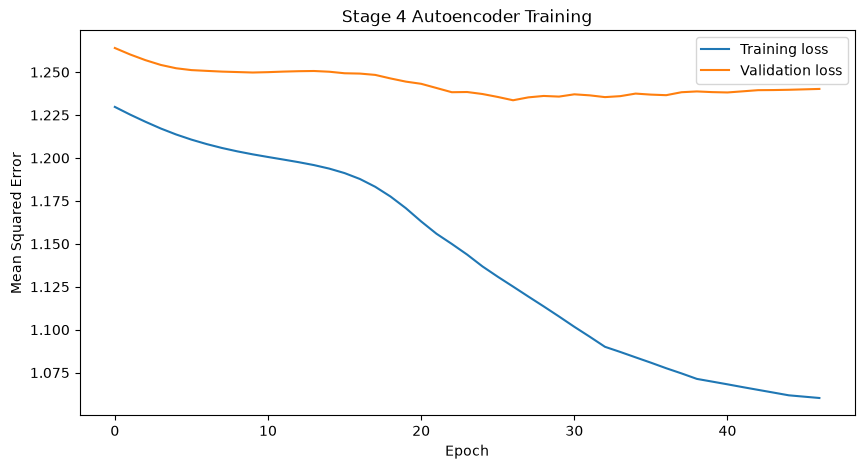

In [28]:
plt.figure(figsize=(10, 5))

plt.plot(
    training_history[
        "train_loss"
    ],

    label="Training loss"
)

plt.plot(
    training_history[
        "validation_loss"
    ],

    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")

plt.title(
    "Stage 4 Autoencoder Training"
)

plt.legend()
plt.show()

In [29]:
def reconstruct_windows(
    trained_model,
    windows,
    batch_size=256
):
    tensor = torch.tensor(
        windows,
        dtype=torch.float32
    )

    loader = DataLoader(
        TensorDataset(tensor),

        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    reconstructions = []

    trained_model.eval()

    with torch.no_grad():

        for (batch,) in loader:
            batch = batch.to(DEVICE)

            reconstruction = (
                trained_model(batch)
            )

            reconstructions.append(
                reconstruction
                .cpu()
                .numpy()
            )

    return np.concatenate(
        reconstructions,
        axis=0
    )


all_reconstructions_scaled = (
    reconstruct_windows(
        trained_model=model,
        windows=all_windows_scaled
    )
)

all_reconstruction_errors = np.mean(
    (
        all_windows_scaled
        - all_reconstructions_scaled
    ) ** 2,

    axis=1
)

print(
    "Reconstructed windows:",
    len(all_reconstruction_errors)
)

Reconstructed windows: 369


In [30]:
# Calibrate the threshold on a third, untouched normal subset.
calibration_errors = (
    all_reconstruction_errors[
        calibration_window_mask
    ]
)

calibration_error_median = np.nanmedian(
    calibration_errors
)

calibration_error_mad = np.nanmedian(
    np.abs(
        calibration_errors
        - calibration_error_median
    )
)

calibration_error_scale = (
    1.4826
    * calibration_error_mad
)

robust_threshold = (
    calibration_error_median
    + AUTOENCODER_CONFIG["threshold_sigma"]
    * calibration_error_scale
)

percentile_threshold = np.quantile(
    calibration_errors,
    AUTOENCODER_CONFIG["threshold_percentile"] / 100.0,
    method="higher"
)

anomaly_threshold = max(
    float(robust_threshold),
    float(percentile_threshold),
    1e-12
)

window_is_anomaly = (
    all_reconstruction_errors
    > anomaly_threshold
)

calibration_false_positive_rate = float(
    np.mean(
        calibration_errors
        > anomaly_threshold
    )
)

print("Median calibration error:", calibration_error_median)
print("Robust threshold:", robust_threshold)
print("Percentile threshold:", percentile_threshold)
print("Final threshold:", anomaly_threshold)
print("Calibration false-positive rate:", calibration_false_positive_rate)
print("Anomalous windows:", window_is_anomaly.sum())


Median calibration error: 1.0018625
Robust threshold: 1.8842641
Percentile threshold: 1.3793938
Final threshold: 1.8842641115188599
Calibration false-positive rate: 0.0
Anomalous windows: 29


In [31]:
candidate_window_mask = (
    window_contains_transit
)

candidate_window_errors = (
    all_reconstruction_errors[
        candidate_window_mask
    ]
)

candidate_anomaly_flags = (
    window_is_anomaly[
        candidate_window_mask
    ]
)

if len(candidate_window_errors) > 0:

    candidate_max_error = float(
        np.nanmax(
            candidate_window_errors
        )
    )

    candidate_median_error = float(
        np.nanmedian(
            candidate_window_errors
        )
    )

    candidate_anomaly_score = (
        candidate_max_error
        / anomaly_threshold
    )

    candidate_detected = bool(
        np.any(
            candidate_anomaly_flags
        )
    )

else:
    candidate_max_error = np.nan
    candidate_median_error = np.nan
    candidate_anomaly_score = np.nan
    candidate_detected = False

print(
    "Transit windows:",
    len(candidate_window_errors)
)

print(
    "Maximum candidate error:",
    candidate_max_error
)

print(
    "Median candidate error:",
    candidate_median_error
)

print(
    "Candidate anomaly score:",
    candidate_anomaly_score
)

print(
    "Candidate detected:",
    candidate_detected
)

Transit windows: 57
Maximum candidate error: 2.496253490447998
Median candidate error: 1.9042527675628662
Candidate anomaly score: 1.3247895956771305
Candidate detected: True


In [32]:
candidate_robust_z = (
    candidate_max_error
    - calibration_error_median
) / (
    calibration_error_scale
    + 1e-12
)

candidate_empirical_p_value = (
    1
    + np.sum(
        calibration_errors
        >= candidate_max_error
    )
) / (
    len(calibration_errors)
    + 1
)

print(
    "Candidate robust Z-score:",
    candidate_robust_z
)

print(
    "Candidate empirical p-value:",
    candidate_empirical_p_value
)

Candidate robust Z-score: 8.467749
Candidate empirical p-value: 0.02564102564102564


In [33]:
# ---------------------------------------------------------
# PHYSICS-INFORMED, TRANSIT-FOCUSED RECONSTRUCTION SCORE
# ---------------------------------------------------------

squared_residuals = (
    all_windows_scaled
    - all_reconstructions_scaled
) ** 2


def calculate_transit_focused_error(
    window_index,
    expected_center
):
    start = window_start_indices[
        window_index
    ]

    end = window_end_indices[
        window_index
    ]

    current_time = model_time[
        start:end
    ]

    current_squared_residual = (
        squared_residuals[
            window_index
        ]
    )

    distance = np.abs(
        current_time
        - expected_center
    )

    # Expected transit region
    in_transit_mask = (
        distance
        <= duration / 2.0
    )

    # Use points sufficiently far from the transit
    # for the local out-of-transit baseline.
    out_of_transit_mask = (
        distance
        >= duration
    )

    if (
        in_transit_mask.sum() < 3
        or out_of_transit_mask.sum() < 10
    ):
        return np.nan

    in_transit_error = np.mean(
        current_squared_residual[
            in_transit_mask
        ]
    )

    out_of_transit_error = np.mean(
        current_squared_residual[
            out_of_transit_mask
        ]
    )

    focused_error_ratio = (
        in_transit_error
        / (
            out_of_transit_error
            + 1e-8
        )
    )

    return float(
        focused_error_ratio
    )

In [34]:
calibration_indices = np.where(
    calibration_window_mask
)[0]

calibration_focused_errors = []

for index in calibration_indices:
    pseudo_center = (
        window_center_times[index]
    )

    score = calculate_transit_focused_error(
        window_index=index,
        expected_center=pseudo_center
    )

    if np.isfinite(score):
        calibration_focused_errors.append(
            score
        )

calibration_focused_errors = np.asarray(
    calibration_focused_errors,
    dtype=float
)

focused_median = np.median(
    calibration_focused_errors
)

focused_mad = np.median(
    np.abs(
        calibration_focused_errors
        - focused_median
    )
)

focused_robust_scale = (
    1.4826
    * focused_mad
)

focused_robust_threshold = (
    focused_median
    + 4.0
    * focused_robust_scale
)

focused_percentile_threshold = (
    np.quantile(
        calibration_focused_errors,
        0.95
    )
)

focused_error_threshold = max(
    focused_robust_threshold,
    focused_percentile_threshold
)

print(
    "Focused normal threshold:",
    focused_error_threshold
)

Focused normal threshold: 1.6219939482688903


In [35]:
candidate_indices = np.where(
    candidate_window_mask
)[0]

candidate_focused_errors = []
used_window_indices = set()

for transit_center in visible_transit_centers:

    distances = np.abs(
        window_center_times[
            candidate_indices
        ]
        - transit_center
    )

    nearest_position = np.argmin(
        distances
    )

    window_index = int(
        candidate_indices[
            nearest_position
        ]
    )

    # Prevent the same sliding window from being used twice.
    if window_index in used_window_indices:
        continue

    used_window_indices.add(
        window_index
    )

    start = window_start_indices[
        window_index
    ]

    end = window_end_indices[
        window_index
    ]

    if not (
        model_time[start]
        <= transit_center
        <= model_time[end - 1]
    ):
        continue

    score = calculate_transit_focused_error(
        window_index=window_index,
        expected_center=transit_center
    )

    if np.isfinite(score):
        candidate_focused_errors.append(
            score
        )

candidate_focused_errors = np.asarray(
    candidate_focused_errors,
    dtype=float
)

candidate_focused_median = float(
    np.median(
        candidate_focused_errors
    )
)

candidate_focused_maximum = float(
    np.max(
        candidate_focused_errors
    )
)

candidate_focused_score = (
    candidate_focused_median
    / focused_error_threshold
)

candidate_focused_repeatability = float(
    np.mean(
        candidate_focused_errors
        > focused_error_threshold
    )
)

physics_confirmed = bool(
    candidate_focused_score > 1.0
    and candidate_focused_repeatability >= 0.50
)

print(
    "Per-transit focused errors:",
    candidate_focused_errors
)

print(
    "Median focused error:",
    candidate_focused_median
)

print(
    "Maximum focused error:",
    candidate_focused_maximum
)

print(
    "Focused anomaly score:",
    candidate_focused_score
)

print(
    "Fraction of transits detected:",
    candidate_focused_repeatability
)

print(
    "Physics-informed confirmation:",
    physics_confirmed
)

Per-transit focused errors: [3.31888199 3.84304857 4.414361   3.0275979  3.63562012]
Median focused error: 3.6356201171875
Maximum focused error: 4.414361000061035
Focused anomaly score: 2.2414510985492258
Fraction of transits detected: 1.0
Physics-informed confirmation: True


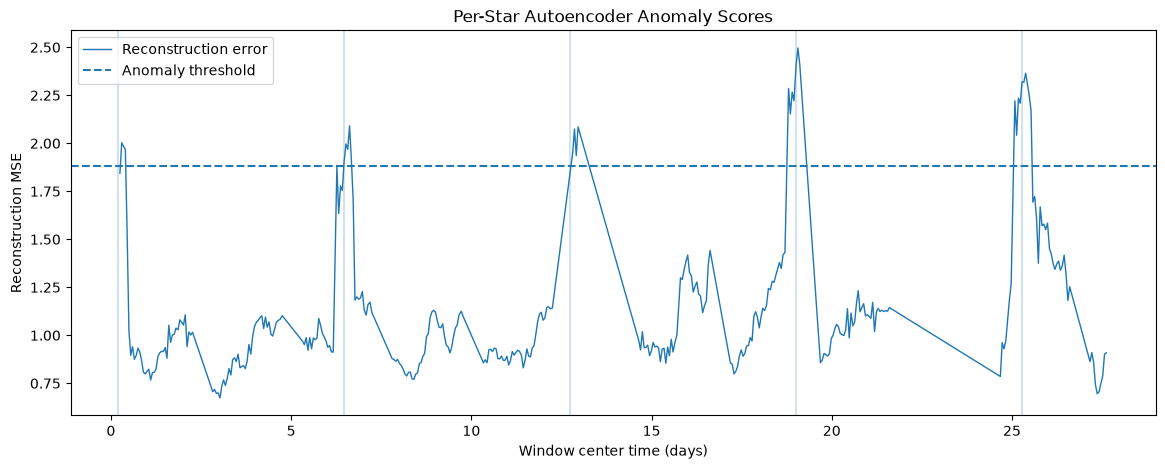

In [36]:
plt.figure(figsize=(14, 5))

plt.plot(
    window_center_times,
    all_reconstruction_errors,
    linewidth=1,
    label="Reconstruction error"
)

plt.axhline(
    anomaly_threshold,
    linestyle="--",
    label="Anomaly threshold"
)

for center in visible_transit_centers:
    plt.axvline(
        center,
        alpha=0.20
    )

plt.xlabel(
    "Window center time (days)"
)

plt.ylabel(
    "Reconstruction MSE"
)

plt.title(
    "Per-Star Autoencoder "
    "Anomaly Scores"
)

plt.legend()
plt.show()

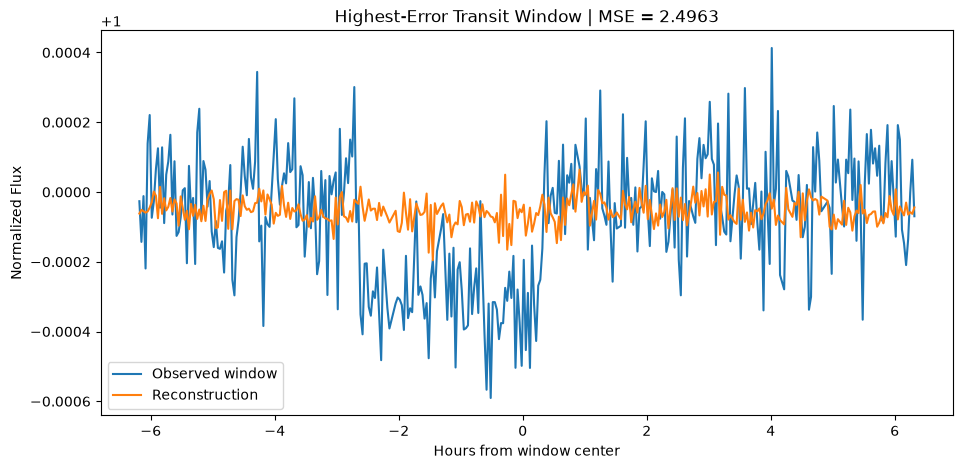

In [37]:
if np.any(candidate_window_mask):
    candidate_indices = np.where(
        candidate_window_mask
    )[0]

    display_window_index = (
        candidate_indices[
            np.argmax(
                all_reconstruction_errors[
                    candidate_indices
                ]
            )
        ]
    )
else:
    display_window_index = int(
        np.argmax(
            all_reconstruction_errors
        )
    )

display_start = window_start_indices[
    display_window_index
]

display_end = window_end_indices[
    display_window_index
]

display_time = model_time[
    display_start:display_end
]

display_time_hours = (
    display_time
    - np.median(display_time)
) * 24.0

display_original_flux = (
    all_windows_raw[
        display_window_index
    ]
)

display_reconstructed_flux = (
    all_reconstructions_scaled[
        display_window_index
    ]
    * normal_scale
    + window_offsets[
        display_window_index,
        0
    ]
)

plt.figure(figsize=(11, 5))

plt.plot(
    display_time_hours,
    display_original_flux,
    label="Observed window"
)

plt.plot(
    display_time_hours,
    display_reconstructed_flux,
    label="Reconstruction"
)

plt.xlabel("Hours from window center")
plt.ylabel("Normalized Flux")

plt.title(
    "Highest-Error Transit Window | "
    f"MSE = "
    f"{all_reconstruction_errors[display_window_index]:.4f}"
)

plt.legend()
plt.show()


In [38]:
def make_trapezoid_profile(
    time_values,
    center,
    total_duration,
    ingress_fraction=0.20
):
    distance = np.abs(
        time_values - center
    )

    half_duration = (
        total_duration / 2.0
    )

    flat_half_duration = (
        half_duration

        * max(
            1.0
            - 2.0
            * ingress_fraction,

            0.0
        )
    )

    profile = np.zeros_like(
        time_values,
        dtype=float
    )

    flat_mask = (
        distance
        <= flat_half_duration
    )

    profile[flat_mask] = 1.0

    slope_mask = (
        (
            distance
            > flat_half_duration
        )
        &
        (
            distance
            < half_duration
        )
    )

    slope_width = max(
        half_duration
        - flat_half_duration,

        1e-12
    )

    profile[slope_mask] = (
        half_duration
        - distance[slope_mask]
    ) / slope_width

    return profile

In [39]:
normal_indices = np.where(
    normal_window_mask
)[0]

normal_errors = (
    all_reconstruction_errors[
        normal_indices
    ]
)

target_normal_error = np.nanmedian(
    normal_errors
)

injection_window_index = (
    normal_indices[
        np.argmin(
            np.abs(
                normal_errors
                - target_normal_error
            )
        )
    ]
)

injection_start = window_start_indices[
    injection_window_index
]

injection_end = window_end_indices[
    injection_window_index
]

injection_time = model_time[
    injection_start:injection_end
]

baseline_window = (
    all_windows_raw[
        injection_window_index
    ].copy()
)

injection_center = np.median(
    injection_time
)

maximum_injection_duration = (
    0.70
    * (
        injection_time[-1]
        - injection_time[0]
    )
)

injection_duration = min(
    max(
        duration,
        3.0 * cadence_days
    ),
    maximum_injection_duration
)

injection_profile = make_trapezoid_profile(
    time_values=injection_time,
    center=injection_center,
    total_duration=injection_duration,
    ingress_fraction=AUTOENCODER_CONFIG[
        "injection_ingress_fraction"
    ]
)

candidate_depth = abs(
    float(
        stage2_data.get(
            "depth_tls",
            np.nan
        )
    )
)

if (
    not np.isfinite(candidate_depth)
    or candidate_depth <= 0
):
    candidate_depth = AUTOENCODER_CONFIG[
        "fallback_injection_depth"
    ]

nominal_injection_depth = (
    candidate_depth
)

def reconstruct_and_score_single_window(
    raw_window
):
    offset = float(
        np.nanmedian(raw_window)
    )

    scaled = (
        raw_window
        - offset
    ) / normal_scale

    scaled = np.clip(
        scaled,
        -AUTOENCODER_CONFIG["clip_scaled_flux"],
        AUTOENCODER_CONFIG["clip_scaled_flux"]
    ).astype(np.float32)

    with torch.no_grad():
        tensor = torch.tensor(
            scaled[None, :],
            dtype=torch.float32,
            device=DEVICE
        )

        reconstructed_scaled = (
            model(tensor)
            .cpu()
            .numpy()[0]
        )

    error = float(
        np.mean(
            (
                scaled
                - reconstructed_scaled
            ) ** 2
        )
    )

    reconstructed_raw = (
        reconstructed_scaled
        * normal_scale
        + offset
    )

    return (
        error,
        reconstructed_raw
    )

injection_results = []

for multiplier in AUTOENCODER_CONFIG[
    "injection_depth_multipliers"
]:
    depth = (
        nominal_injection_depth
        * float(multiplier)
    )

    trial_window = (
        baseline_window
        - depth
        * injection_profile
    )

    trial_error, _ = (
        reconstruct_and_score_single_window(
            trial_window
        )
    )

    injection_results.append({
        "multiplier": float(multiplier),
        "depth": float(depth),
        "error": float(trial_error),
        "detected": bool(
            trial_error
            > anomaly_threshold
        )
    })

injected_window = (
    baseline_window
    - nominal_injection_depth
    * injection_profile
)

(
    injected_error,
    injected_reconstruction_flux
) = reconstruct_and_score_single_window(
    injected_window
)

baseline_window_error = float(
    all_reconstruction_errors[
        injection_window_index
    ]
)

injection_detected = bool(
    injected_error
    > anomaly_threshold
)

print("Candidate-depth injection:", nominal_injection_depth)
print("Baseline error:", baseline_window_error)
print("Injected error:", injected_error)
print("Threshold:", anomaly_threshold)
print("Injection detected:", injection_detected)
print("Depth-sweep results:", injection_results)


Candidate-depth injection: 0.9997072757998143
Baseline error: 0.9850387573242188
Injected error: 32.02798843383789
Threshold: 1.8842641115188599
Injection detected: True
Depth-sweep results: [{'multiplier': 0.5, 'depth': 0.49985363789990717, 'error': 32.02798843383789, 'detected': True}, {'multiplier': 1.0, 'depth': 0.9997072757998143, 'error': 32.02798843383789, 'detected': True}, {'multiplier': 2.0, 'depth': 1.9994145515996287, 'error': 32.02798843383789, 'detected': True}]


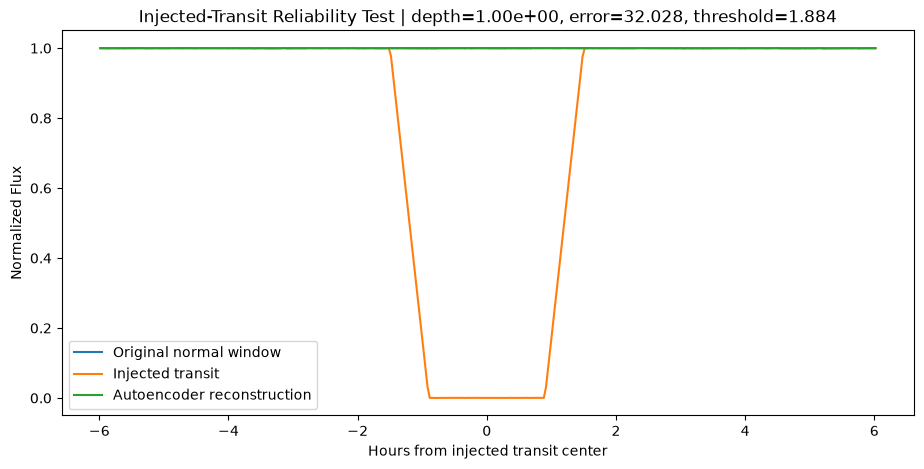

In [40]:
injection_time_hours = (
    injection_time
    - injection_center
) * 24.0

plt.figure(figsize=(11, 5))

plt.plot(
    injection_time_hours,
    baseline_window,
    label="Original normal window"
)

plt.plot(
    injection_time_hours,
    injected_window,
    label="Injected transit"
)

plt.plot(
    injection_time_hours,
    injected_reconstruction_flux,
    label="Autoencoder reconstruction"
)

plt.xlabel(
    "Hours from injected transit center"
)

plt.ylabel("Normalized Flux")

plt.title(
    "Injected-Transit Reliability Test | "
    f"depth={nominal_injection_depth:.2e}, "
    f"error={injected_error:.3f}, "
    f"threshold={anomaly_threshold:.3f}"
)

plt.legend()
plt.show()


In [41]:
def safe_float(value):
    try:
        converted = float(value)

        if np.isfinite(converted):
            return converted

    except (TypeError, ValueError):
        pass

    return np.nan


tic_id = stage1_data.get(
    "tic_id"
)

crowdsap = safe_float(
    stage1_data.get(
        "crowdsap",
        np.nan
    )
)

gaia_blend_risk = safe_float(
    stage1_data.get(
        "gaia_blend_risk",
        np.nan
    )
)

blend_metric = np.nan
blend_metric_source = "unavailable"

if np.isfinite(gaia_blend_risk):

    blend_metric = (
        gaia_blend_risk
    )

    blend_metric_source = (
        "gaia_blend_risk"
    )

elif (
    np.isfinite(crowdsap)
    and 0.0 <= crowdsap <= 1.0
):
    blend_metric = (
        1.0 - crowdsap
    )

    blend_metric_source = (
        "1 - CROWDSAP proxy"
    )

blend_unreliable = bool(
    np.isfinite(blend_metric)

    and blend_metric
    > AUTOENCODER_CONFIG[
        "blend_risk_threshold"
    ]
)

normal_flux_points = (
    flux_normalized[
        ~predicted_transit_mask
    ]
)

normal_flux_median = (
    np.nanmedian(
        normal_flux_points
    )
)

normal_flux_mad = (
    np.nanmedian(
        np.abs(
            normal_flux_points
            - normal_flux_median
        )
    )
)

normal_scatter = float(
    1.4826
    * normal_flux_mad
)

high_variability_warning = bool(
    normal_scatter
    > AUTOENCODER_CONFIG[
        "variability_scatter_threshold"
    ]
)

reliability_reasons = []

if not injection_detected:
    reliability_reasons.append(
        "injected_transit_not_detected"
    )

if blend_unreliable:
    reliability_reasons.append(
        "high_blend_risk"
    )

if high_variability_warning:
    reliability_reasons.append(
        "high_out_of_transit_variability"
    )

autoencoder_reliable = (
    len(reliability_reasons) == 0
)

print("TIC ID:", tic_id)

print(
    "Blend metric:",
    blend_metric
)

print(
    "Blend source:",
    blend_metric_source
)

print(
    "Normal scatter:",
    normal_scatter
)

print(
    "Autoencoder reliable:",
    autoencoder_reliable
)

print(
    "Reliability reasons:",
    reliability_reasons
)

TIC ID: 261136679
Blend metric: 0.0003415900000000027
Blend source: 1 - CROWDSAP proxy
Normal scatter: 0.00011919696968883292
Autoencoder reliable: True
Reliability reasons: []


In [42]:
print("=" * 65)

print(
    "STAGE 4: PER-STAR "
    "AUTOENCODER RESULT"
)

print("=" * 65)

print("TIC ID:", tic_id)
print("Device:", DEVICE)
print()

print(
    "Training windows:",
    len(train_windows)
)

print(
    "Validation windows:",
    len(validation_windows)
)

print(
    "Completed epochs:",
    completed_epochs
)

print(
    "Best validation loss:",
    best_validation_loss
)

print()

print(
    "Anomaly threshold:",
    anomaly_threshold
)

print(
    "Candidate maximum error:",
    candidate_max_error
)

print(
    "Candidate anomaly score:",
    candidate_anomaly_score
)

print(
    "Candidate detected:",
    candidate_detected
)

print()

print(
    "Injection detected:",
    injection_detected
)

print(
    "Blend metric:",
    blend_metric
)

print(
    "Normal scatter:",
    normal_scatter
)

print()

print(
    "Autoencoder reliable:",
    autoencoder_reliable
)

print(
    "Reliability reasons:",
    reliability_reasons
)

STAGE 4: PER-STAR AUTOENCODER RESULT
TIC ID: 261136679
Device: cpu

Training windows: 144
Validation windows: 44
Completed epochs: 47
Best validation loss: 1.233610987663269

Anomaly threshold: 1.8842641115188599
Candidate maximum error: 2.496253490447998
Candidate anomaly score: 1.3247895956771305
Candidate detected: True

Injection detected: True
Blend metric: 0.0003415900000000027
Normal scatter: 0.00011919696968883292

Autoencoder reliable: True
Reliability reasons: []


In [43]:
checkpoint = {
    "model_state_dict": model.state_dict(),

    "architecture": {
        "type": "conv1d_autoencoder",
        "input_size": AUTOENCODER_CONFIG["window_size"],
        "channels": [16, 32, 64],
        "latent_size": AUTOENCODER_CONFIG["latent_size"]
    },

    "preprocessing": {
        "mode": "per_window_median_then_training_mad",
        "normal_scale": float(normal_scale)
    },

    "config": AUTOENCODER_CONFIG
}

torch.save(
    checkpoint,
    model_path
)

print("Model saved successfully!")
print(model_path)


Model saved successfully!
/content/drive/MyDrive/exoplanet_pipeline/models\stage4_per_star_autoencoder.pt


In [44]:
# Make saving robust even when Stage 3 is intentionally absent.
stage3_available = bool(
    os.path.isfile(stage3_path)
)

if stage3_available and stage3_data is None:
    with open(stage3_path, "rb") as f:
        stage3_data = pickle.load(f)

if stage3_data is not None:
    stage3_decision = stage3_data.get(
        "decision",
        stage3_data.get("status")
    )
else:
    stage3_decision = None

stage4_data = {
    "tic_id": tic_id,

    "stage3": {
        "available": stage3_available,
        "decision": stage3_decision
    },

    "candidate": {
        "period": period,
        "duration": duration,
        "t0": t0,
        "sde": sde,
        "depth_tls": stage2_data.get(
            "depth_tls",
            np.nan
        )
    },

    "windowing": {
        "window_size": AUTOENCODER_CONFIG["window_size"],
        "stride": AUTOENCODER_CONFIG["stride"],
        "cadence_minutes": float(cadence_minutes),
        "window_hours": float(window_hours),
        "total_windows": int(len(all_windows_raw)),
        "training_windows": int(len(train_windows)),
        "validation_windows": int(len(validation_windows)),
        "calibration_windows": int(len(calibration_windows)),
        "candidate_windows": int(
            candidate_window_mask.sum()
        )
    },

    "training": {
        "completed_epochs": int(completed_epochs),
        "best_validation_loss": float(
            best_validation_loss
        ),
        "train_loss": np.asarray(
            training_history["train_loss"],
            dtype=float
        ),
        "validation_loss": np.asarray(
            training_history["validation_loss"],
            dtype=float
        ),
        "learning_rate": np.asarray(
            training_history["learning_rate"],
            dtype=float
        )
    },

    "anomaly_detection": {
        "threshold": float(anomaly_threshold),
        "calibration_false_positive_rate": float(
            calibration_false_positive_rate
        ),
        "window_center_times": window_center_times,
        "window_errors": all_reconstruction_errors,
        "window_is_anomaly": window_is_anomaly,
        "window_contains_transit": window_contains_transit,
        "candidate_max_error": float(candidate_max_error),
        "candidate_median_error": float(candidate_median_error),
        "candidate_anomaly_score": float(
            candidate_anomaly_score
        ),
        "candidate_detected": bool(candidate_detected)
    },

    "reliability": {
        "nominal_injection_depth": float(
            nominal_injection_depth
        ),
        "injection_depth_sweep": injection_results,
        "baseline_window_error": float(
            baseline_window_error
        ),
        "injected_window_error": float(injected_error),
        "injection_detected": bool(injection_detected),
        "blend_metric": float(blend_metric),
        "blend_metric_source": blend_metric_source,
        "blend_unreliable": bool(blend_unreliable),
        "normal_scatter": float(normal_scatter),
        "high_variability_warning": bool(
            high_variability_warning
        ),
        "autoencoder_reliable": bool(
            autoencoder_reliable
        ),
        "reliability_reasons": reliability_reasons
    },

    "preprocessing": {
        "normalization_mode": normalization_mode,
        "window_centering": "per_window_median",
        "normal_center": float(normal_center),
        "normal_scale": float(normal_scale),
        "scaler_fit_subset": "training_windows_only"
    },

    "model_path": model_path,
    "config": AUTOENCODER_CONFIG
}

with open(stage4_path, "wb") as f:
    pickle.dump(
        stage4_data,
        f
    )

print("Stage 4 output saved successfully!")
print(stage4_path)


Stage 4 output saved successfully!
/content/drive/MyDrive/exoplanet_pipeline/data\stage4_output.pkl


In [45]:
with open(stage4_path, "rb") as f:
    saved_stage4_data = (
        pickle.load(f)
    )

print(
    saved_stage4_data.keys()
)

print(
    "Candidate detected:",
    saved_stage4_data[
        "anomaly_detection"
    ]["candidate_detected"]
)

print(
    "Candidate anomaly score:",
    saved_stage4_data[
        "anomaly_detection"
    ]["candidate_anomaly_score"]
)

print(
    "Autoencoder reliable:",
    saved_stage4_data[
        "reliability"
    ]["autoencoder_reliable"]
)

print(
    "Reliability reasons:",
    saved_stage4_data[
        "reliability"
    ]["reliability_reasons"]
)

print(
    "Model path:",
    saved_stage4_data[
        "model_path"
    ]
)

dict_keys(['tic_id', 'stage3', 'candidate', 'windowing', 'training', 'anomaly_detection', 'reliability', 'preprocessing', 'model_path', 'config'])
Candidate detected: True
Candidate anomaly score: 1.3247895956771305
Autoencoder reliable: True
Reliability reasons: []
Model path: /content/drive/MyDrive/exoplanet_pipeline/models\stage4_per_star_autoencoder.pt
